# Part 2: Genres and communities and plotting

* *Write about genres and modularity.*

In order to extract the genre information from all the artists pages, I started by loading the network from Github. Each node contains the name of the artist and its corresponding page content.

In [32]:
import urllib
import networkx as nx
import io

# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_assignment2/refs/heads/denisa/network.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

✓ Network loaded successfully!
  Nodes: 486
  Edges: 7655


I converted the directed graph to undirected.

In [33]:
network = network.to_undirected()

With the help of an LLM, I defined a function to extract the genre information from each page.

In [34]:
import os
import json
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import urllib.request

# Helper function to clean the genre text
def clean_genre(genre):
    # Remove reference tags like <ref>...</ref>
    genre = re.sub(r'<ref[^>]*>.*?</ref>', '', genre, flags=re.DOTALL)
    # Remove {{nowrap|...}}
    genre = re.sub(r'\{\{nowrap\|(.*?)\}\}', r'\1', genre)
    # Remove any remaining {{ }}
    genre = re.sub(r'\{\{[^}]*\}\}', '', genre)
    # Remove brackets
    genre = re.sub(r'[\[\]]', '', genre)
    # Clean whitespace
    genre = ' '.join(genre.split())
    # Change to lowercase
    genre = genre.lower().strip()
    
    # Map various rock variants to single genre
    rock_variants = {
        "rock'n'roll": "rock and roll",
        "rock & roll": "rock and roll",
        "rock 'n' roll": "rock and roll",
        "rock n roll": "rock and roll",
        "rock-and-roll": "rock and roll"
    }
    
    if genre in rock_variants:
        return rock_variants[genre]
    
    return genre

# Extract genres list from the wikipedia pages
def extract_genres(content):
    # Parse the JSON structure
    data = json.loads(content)
    
    # Navigate to the wikitext content
    pages = data.get('query', {}).get('pages', {})
    if not pages:
        return []
    
    # Get the page
    page_id = list(pages.keys())[0]
    wikitext = pages[page_id].get('revisions', [{}])[0].get('slots', {}).get('main', {}).get('*', '')
    
    if not wikitext:
        return []
    
    # Extract the Infobox musical artist section
    infobox_pattern = r'\{\{Infobox musical artist(.*?)\n\}\}'
    infobox_match = re.search(infobox_pattern, wikitext, re.DOTALL | re.IGNORECASE)
    
    if not infobox_match:
        return []
    
    infobox_content = infobox_match.group(1)
    
    # Extract genre field
    # Look for | genre = followed by content until the next | field
    genre_pattern = r'\|\s*genre\s*=\s*(.*?)(?=\n\||\n\}\})'
    genre_match = re.search(genre_pattern, infobox_content, re.DOTALL | re.IGNORECASE)
    
    if not genre_match:
        return []

    genre_content = genre_match.group(1).strip()
    
    # Parse genres - they can be in various formats
    genres = []
    
    # Remove {{flatlist| and }} wrappers
    genre_content = re.sub(r'\{\{flatlist\|', '', genre_content, flags=re.IGNORECASE)
    genre_content = re.sub(r'\}\}', '', genre_content)
    
    # Remove wiki formatting like [[Genre]] or [[Genre|display text]]
    # Pattern: [[link]] or [[link|text]]
    wiki_links = re.findall(r'\[\[([^\]|]+)(?:\|[^\]]+)?\]\]', genre_content)
    
    if wiki_links:
        # If we found wiki links, use those
        genres = wiki_links
    else:
        # Otherwise, split by common separators
        # Remove any remaining markup
        genre_content = re.sub(r'<[^>]+>', '', genre_content)
        genre_content = re.sub(r'\*\s*', '', genre_content)
        
        # Split by newlines, commas or bullets
        genre_list = re.split(r'[\n,•]', genre_content)
        genres = [g.strip() for g in genre_list if g.strip()]
    
    # Clean genres
    cleaned_genres = []
    for genre in genres:
        if genre:
            cleaned_genre = clean_genre(genre)
            if cleaned_genre != 'allmusic': # Remove allmusic (discovered during testing)
                cleaned_genres.append(cleaned_genre)
    
    return cleaned_genres

I extracted the genres from each node and added them as a node attribute.

In [35]:
artist_genres = []

for n in network.nodes():
    # Add genres as a list attribute
    genres = extract_genres(network.nodes[n]['content'])
    artist_genres.append(genres)
    network.nodes[n]['genres'] = genres

With the help of an LLM, I created a function that generates statistics for genres. The function returns:
1. The number of nodes with genres
2. The average number of genres per node
3. The total number of distinct genres
4. The top 15 genres

In [36]:
# Generate statistics for the nodes with genres
def generate_statistics(nodes_with_genres):
    # 1. Number of nodes with genres
    num_artists_with_genres = len(nodes_with_genres)
    print(f"\n1. Number of artists with genres: {num_artists_with_genres}")
    
    # 2. Average number of genres per node
    total_genres = sum(len(network.nodes[node]['genres']) for node in nodes_with_genres)
    avg_genres = total_genres / num_artists_with_genres if num_artists_with_genres > 0 else 0
    print(f"2. Average number of genres per artist: {avg_genres:.2f}")
    
    # 3. Total number of distinct genres
    all_genres = set()
    for node in nodes_with_genres:
        genres = network.nodes[node]['genres']
        all_genres.update(genres)
    num_distinct_genres = len(all_genres)
    print(f"3. Total number of distinct genres: {num_distinct_genres}")
    
    # 4. Top 15 genres histogram
    genre_counter = Counter()
    for node in nodes_with_genres:
        genres = network.nodes[node]['genres']
        genre_counter.update(genres)
    
    top_15 = genre_counter.most_common(15)
    
    print(f"\n4. Top 15 genres:")
    for i, (genre, count) in enumerate(top_15, 1):
        print(f"   {i:2d}. {genre:30s} - {count:3d} artists")
    
    # Create histogram
    if top_15:
        genres_list, counts = zip(*top_15)
        
        plt.figure(figsize=(14, 8))
        bars = plt.barh(range(len(genres_list)), counts, color='steelblue')
        plt.yticks(range(len(genres_list)), genres_list)
        plt.xlabel('Number of Artists', fontsize=12)
        plt.ylabel('Genre', fontsize=12)
        plt.title('Top 15 Genres by Artist Count', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()  # Highest at top
        
        # Add count labels on bars
        for i, (bar, count) in enumerate(zip(bars, counts)):
            plt.text(count + 0.5, i, str(count), va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'num_artists_with_genres': num_artists_with_genres,
        'avg_genres_per_artist': avg_genres,
        'num_distinct_genres': num_distinct_genres,
        'top_15_genres': top_15
    }

I generate statistics for the nodes which I have extracted genres from.


1. Number of artists with genres: 148
2. Average number of genres per artist: 3.84
3. Total number of distinct genres: 152

4. Top 15 genres:
    1. hard rock                      -  33 artists
    2. rock music                     -  32 artists
    3. pop rock                       -  30 artists
    4. pop music                      -  23 artists
    5. alternative rock               -  22 artists
    6. blues rock                     -  22 artists
    7. soft rock                      -  20 artists
    8. art rock                       -  13 artists
    9. heavy metal music              -  13 artists
   10. rock and roll                  -  13 artists
   11. country rock                   -  13 artists
   12. folk rock                      -  13 artists
   13. southern rock                  -  11 artists
   14. indie rock                     -  10 artists
   15. new wave music                 -  10 artists


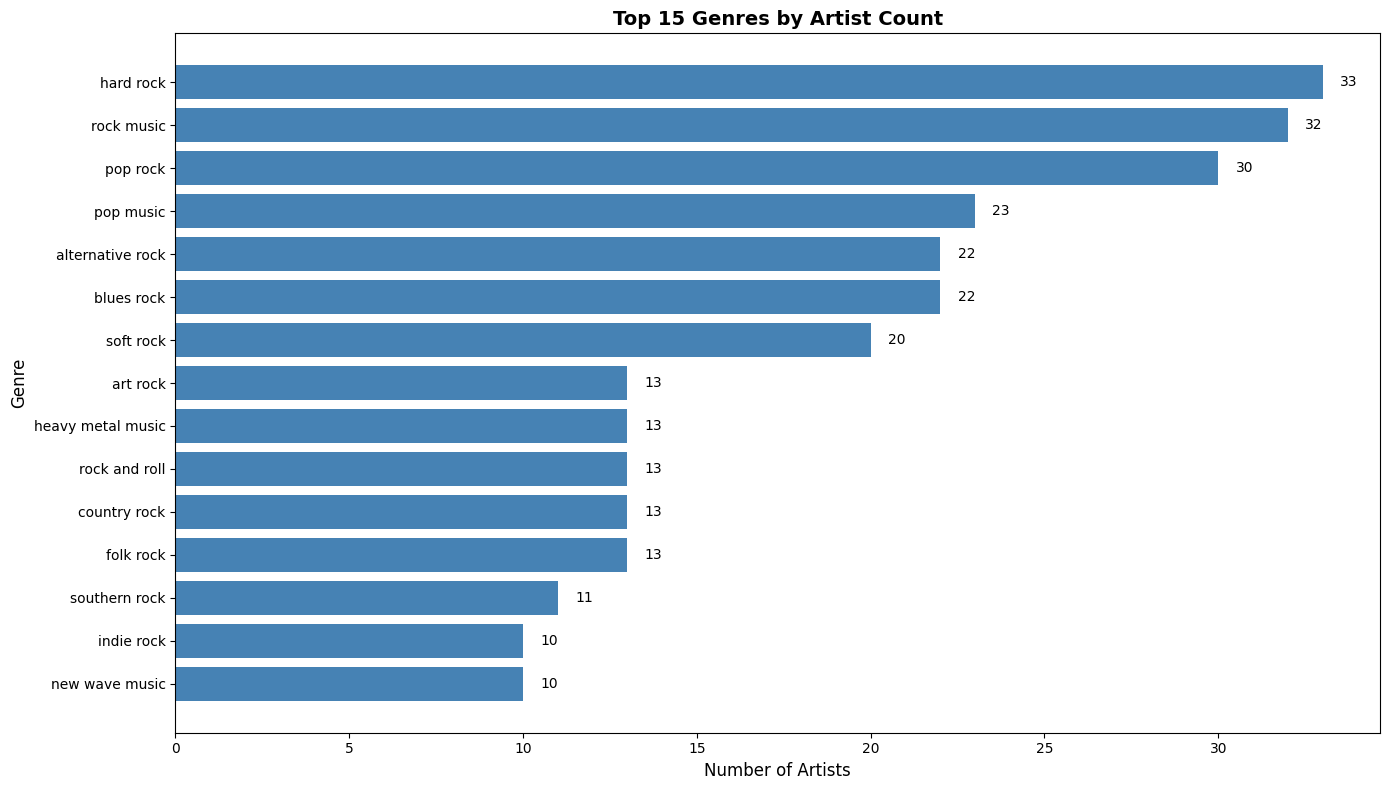

In [37]:
nodes_with_genres = [n for n in network.nodes() if network.nodes[n]['genres']]
stats = generate_statistics(nodes_with_genres)

As expected, the genres are mostly subsets of the rock genre. It can also be observed that Wikipedia considers subgenres of rock but also the broad genres like 'rock music' or 'pop music' when defining the artists. Also an interesting mention is that 'pop music' also appears in the list, so a lot of the artists are actually blending rock and pop music.

For computing modularity, I continue to work with a subnetwork of nodes containing genre information.

In [38]:
subnetwork = network.subgraph(nodes_with_genres)

According to the [Network Science book - Section 9.4](https://networksciencebook.com/chapter/9#modularity:~:text=Section%209.4-,Modularity,-In%20a%20randomly), modularity is defined as a measure of a partition's quality, helping to decide if a community partition is better than another one.

TBD: ADD MORE ABOUT MODULARITY

* *Detect the communities, discuss the value of modularity in comparison to the genres.*

I first created a partition where each node is characterized by the first genre in its list of genres. Each community is the group of nodes that share the same genre.

In [49]:
# Create a partition based on the first genre in the node's list of genres
def create_first_genre_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if genres:
            labels[node] = genres[0]
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


first_partition = create_first_genre_partition(subnetwork)
for key, members in first_partition.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

reggae (1 members):
  - weezer

beat music (1 members):
  - glenn frey

blues rock (5 members):
  - grand funk railroad
  - bullet for my valentine
  - simon & garfunkel
  - bob seger|bob seger & the silver bullet band
  - zz top

hard rock (13 members):
  - fleetwood mac
  - seether
  - manfred mann
  - steve miller band
  - anthrax (american band)|anthrax
  - the cranberries
  - the allman brothers band
  - flyleaf (band)|flyleaf
  - the all-american rejects
  - sonic youth
  - hole (band)|hole
  - jimmy eat world
  - chuck berry

garage rock (1 members):
  - the tragically hip

soft rock (3 members):
  - the alan parsons project
  - metallica
  - green day

pop rock (6 members):
  - coheed and cambria
  - boys like girls
  - thin lizzy
  - great white
  - skid row (american band)|skid row
  - the used

thrash metal (2 members):
  - primus (band)|primus
  - led zeppelin

rock music (29 members):
  - collective soul
  - highly suspect
  - slade
  - modest mouse
  - kaiser chiefs
  - t

I defined a function to compute modularity based on the equation 9.12 from the [Network Science book - Section 9.4](https://networksciencebook.com/chapter/9#modularity:~:text=Section%209.4-,Modularity,-In%20a%20randomly).

In [50]:
# Compute modularity based on the equation
def calculate_modularity(G, partition):
    # Get total number of edges
    L = G.number_of_edges()
    
    # Calculate modularity
    modularity = 0.0
    
    for community, nodes in partition.items():
        # Calculate lc: number of edges inside this community
        lc = 0
        for i, node_i in enumerate(nodes):
            for node_j in nodes[i+1:]:  # Only check pairs once
                if G.has_edge(node_i, node_j):
                    lc += 1
        
        # Calculate dc: sum of degrees of all nodes in this community
        dc = sum(G.degree(node) for node in nodes)
        
        # Add contribution of this community to modularity
        # Q = Σc [lc/L - (dc/2L)²]
        modularity += (lc / L) - (dc / (2 * L)) ** 2
    
    return modularity

print(calculate_modularity(subnetwork, first_partition))

0.0004376807309614669


The partition created leads to a slightly higher than 0 modularity, so the option of defining communities by the first genre in the list is suboptimal.

I continued by checking the modularity obtained for a partition defined by a random genre in the node's list of genres.

In [45]:
import random

# Create a partition based on a random genre from the list
def create_genre_random_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if genres:
            labels[node] = random.choice(genres)
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


ranodm_partition = create_genre_random_partition(subnetwork)
for key, members in ranodm_partition.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

dub music (1 members):
  - weezer

beat music (4 members):
  - glenn frey
  - slade
  - bruce springsteen
  - travis (band)|travis

garage rock revival (3 members):
  - grand funk railroad
  - jefferson starship
  - rod stewart

jazz rock (3 members):
  - fleetwood mac
  - kiss (band)|kiss
  - the kinks

hard rock (10 members):
  - seether
  - sepultura
  - manfred mann
  - anthrax (american band)|anthrax
  - the cranberries
  - the allman brothers band
  - flyleaf (band)|flyleaf
  - fall out boy
  - sonic youth
  - chuck berry

garage rock (1 members):
  - the tragically hip

adult contemporary music (1 members):
  - the alan parsons project

alternative rock (6 members):
  - coheed and cambria
  - tenacious d
  - u2
  - rob zombie
  - frank zappa
  - mike and the mechanics|mike + the mechanics

thrash metal (2 members):
  - primus (band)|primus
  - led zeppelin

folk rock (5 members):
  - collective soul
  - the mamas & the papas
  - john lennon
  - jimmy eat world
  - the presidents

The modularity of the random partition is negative, so it is worse than choosing the first genre from the genre list as a way to define communities.

In [46]:
print(calculate_modularity(subnetwork, ranodm_partition))

-0.017287811457765555


I continued by creating a partition with the help of the Louvain Community Detection Algorithm.

In [47]:
louvain_partition = nx.community.louvain_communities(subnetwork, seed=123)

# Convert the list to a dictionary to use the same calculate_modularity function defined above
louvain_dict = {i+1: list(members) for i, members in enumerate(louvain_partition)}

for key, members in louvain_dict.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

1 (1 members):
  - collective soul

2 (1 members):
  - lifehouse (band)|lifehouse

3 (11 members):
  - glenn frey
  - supertramp
  - tenacious d
  - fleetwood mac
  - journey (band)|journey
  - thin lizzy
  - blue october
  - coheed and cambria
  - tommy james and the shondells
  - kaiser chiefs
  - jefferson starship

4 (1 members):
  - stevie ray vaughan|stevie ray vaughan and double trouble

5 (30 members):
  - steely dan
  - weezer
  - billy squier
  - the hollies
  - system of a down
  - steve miller band
  - breaking benjamin
  - chubby checker
  - harry chapin
  - no doubt
  - highly suspect
  - bruce springsteen
  - eddie money
  - gin blossoms
  - edgar winter|the edgar winter group
  - the sweet|sweet
  - christopher cross
  - shakin' stevens
  - the outfield
  - simon & garfunkel
  - sheryl crow
  - vampire weekend
  - men at work
  - sting (musician)|sting
  - sublime (band)|sublime
  - green day
  - 10 years (band)|10 years
  - genesis (band)|genesis
  - george thorogood|g

The modularity for the Louvain partition is the highest, defining the partition as optimal.

In [48]:
print(calculate_modularity(subnetwork, louvain_dict))

0.29350130726804075


* *Calculate the matrix D and discuss your findings.*

I used an LLM to help with creating the confusion matrix D plotting the 7 most common genres against the 7 largest communities.

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns

def create_D_matrix(partition):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Get top 7 genres
    top_genres = [g for g, _ in stats['top_15_genres'][:7]]

    # Get top 7 communities (by size)
    community_sizes = [(idx, len(c)) for idx, c in enumerate(community_list)]
    community_sizes.sort(key=lambda x: x[1], reverse=True)
    top_community_indices = [idx for idx, _ in community_sizes[:7]]
    top_communities = [community_list[idx] for idx in top_community_indices]

    # Map node to its community index
    node_to_community = {}
    for idx in top_community_indices:
        for node in community_list[idx]:
            node_to_community[node] = idx

    # Initialize confusion matrix
    conf_matrix = np.zeros((7, 7), dtype=int)

    # For each node, count genre-community overlap
    for node in subnetwork.nodes():
        genres = subnetwork.nodes[node]['genres']
        if not genres:
            continue
        # Only consider nodes in top communities
        if node not in node_to_community:
            continue
        comm_idx = top_community_indices.index(node_to_community[node])
        # For each genre, if it is in top genres, increment
        for genre in genres:
            if genre in top_genres:
                genre_idx = top_genres.index(genre)
                conf_matrix[genre_idx, comm_idx] += 1

    # Create DataFrame for display
    conf_df = pd.DataFrame(conf_matrix, index=top_genres, columns=[f'Community {list(partition.keys())[i]}' for i in range(7)])
    print("Confusion Matrix (Genres vs Communities):")
    print(conf_df)

    # Interpretation
    plt.figure(figsize=(8,6))
    sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Community")
    plt.ylabel("Genre")
    plt.title("Confusion Matrix: Genre vs Community")
    plt.show()

I first checked the confusion matrix for the partition defined by the first genre in the genre list.

Confusion Matrix (Genres vs Communities):
                  Community reggae  Community beat music  \
hard rock                        6                    13   
rock music                      29                     0   
pop rock                         7                     1   
pop music                       11                     0   
alternative rock                 1                     1   
blues rock                       0                     4   
soft rock                        7                     0   

                  Community blues rock  Community hard rock  \
hard rock                            4                    1   
rock music                           0                    0   
pop rock                             2                    0   
pop music                            0                    2   
alternative rock                    10                    0   
blues rock                           0                    0   
soft rock                           

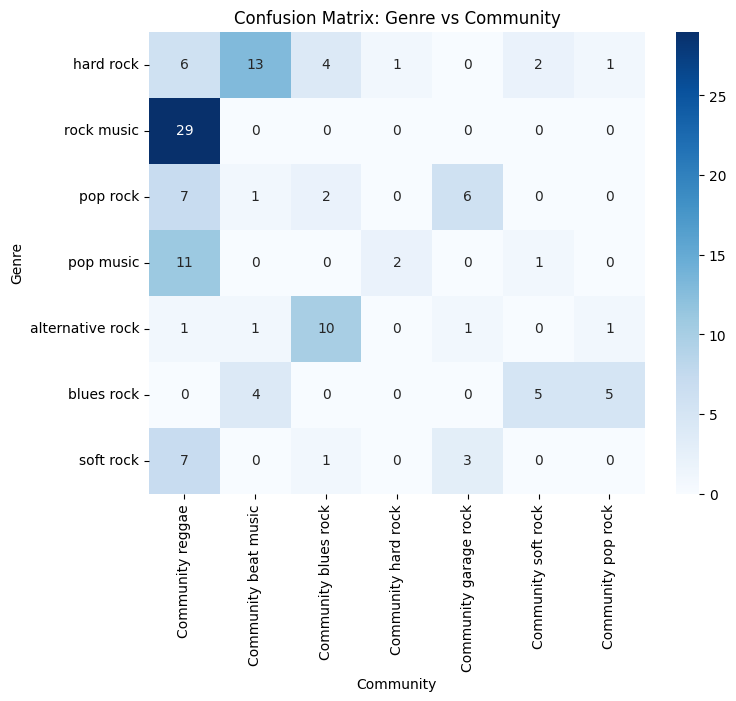

In [65]:
create_D_matrix(first_partition)

TBD: WRITE ABOUT CONFUSION MATRIX.

I also plotted the confusion matrix for the Louvain partition.

Confusion Matrix (Genres vs Communities):
                  Community 1  Community 2  Community 3  Community 4  \
hard rock                  11            4            6            5   
rock music                  8           10            3            5   
pop rock                    5            4            7            5   
pop music                   3            8            5            2   
alternative rock            3            3            9            2   
blues rock                  4            5            6            2   
soft rock                   2            5            3            3   

                  Community 5  Community 6  Community 7  
hard rock                   6            1            0  
rock music                  0            5            1  
pop rock                    2            5            1  
pop music                   1            2            1  
alternative rock            2            3            0  
blues rock                  2    

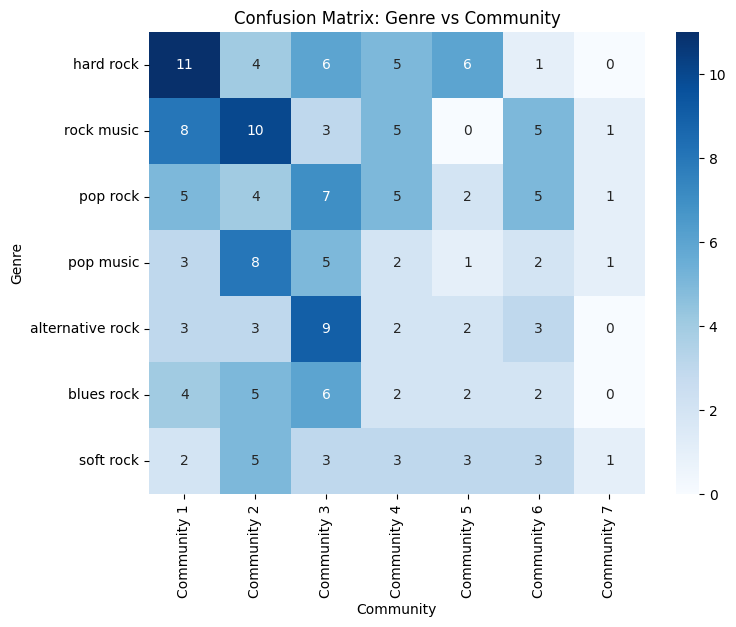

In [66]:
create_D_matrix(louvain_dict)

* *Plot the communities and comment on your results.*

With the help of an LLM, I created a function to plot the network with the Force Atlas algorithm.

In [99]:
import matplotlib.colors as mcolors

# Create color map based on partition
def create_color_map(partition, subnetwork):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Generate a color for each community
    num_communities = len(community_list)
    color_map = list(mcolors.TABLEAU_COLORS.values())
    while len(color_map) < num_communities:
        color_map += list(mcolors.CSS4_COLORS.values())
    colors = color_map[:num_communities]

    # Map node to its community color
    node_colors = []
    node_to_color = {}
    for idx, community in enumerate(community_list):
        for node in community:
            node_to_color[node] = colors[idx]

    for node in subnetwork.nodes():
        node_colors.append(node_to_color.get(node, "#cccccc")) 
    return node_colors

# Plot graph with Force Atlas
def plot_force_atlas(partition, subnetwork):
    node_colors = create_color_map(partition, subnetwork)
    pos = nx.forceatlas2_layout(subnetwork, scaling_ratio=20, gravity=0.1)
    fig, ax = plt.subplots(figsize=(12, 8))
    nx.draw(subnetwork, pos=pos, node_color=node_colors, ax=ax, with_labels=False, node_size=50)
    ax.set_title("Force-Atlas layout colored by community", fontsize=16, pad=14)
    plt.show()

I plotted based on the first genre partition first.

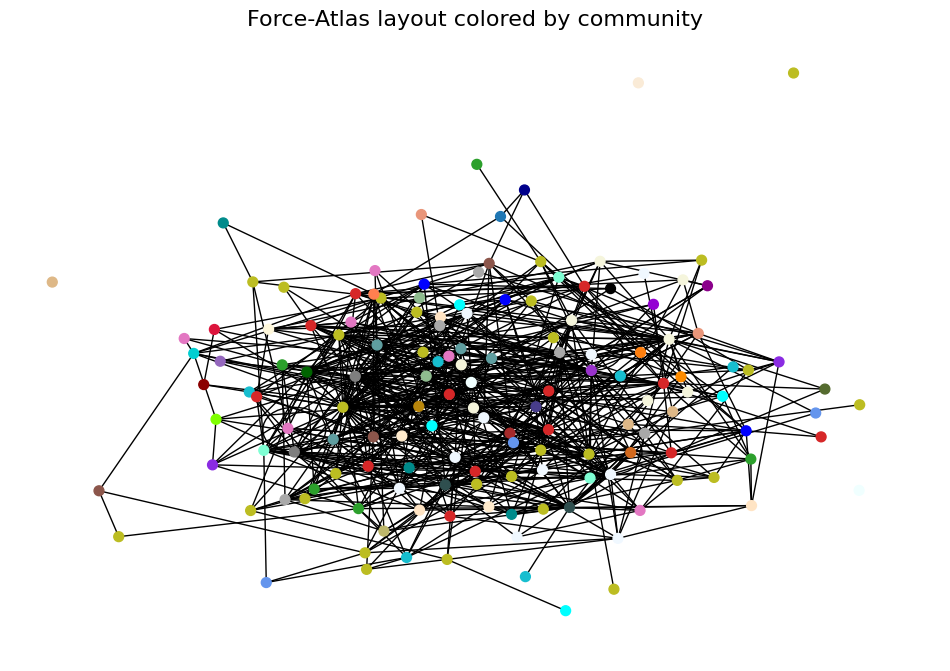

In [100]:
plot_force_atlas(first_partition, subnetwork)

Then, I plotted based on the Louvain partition.

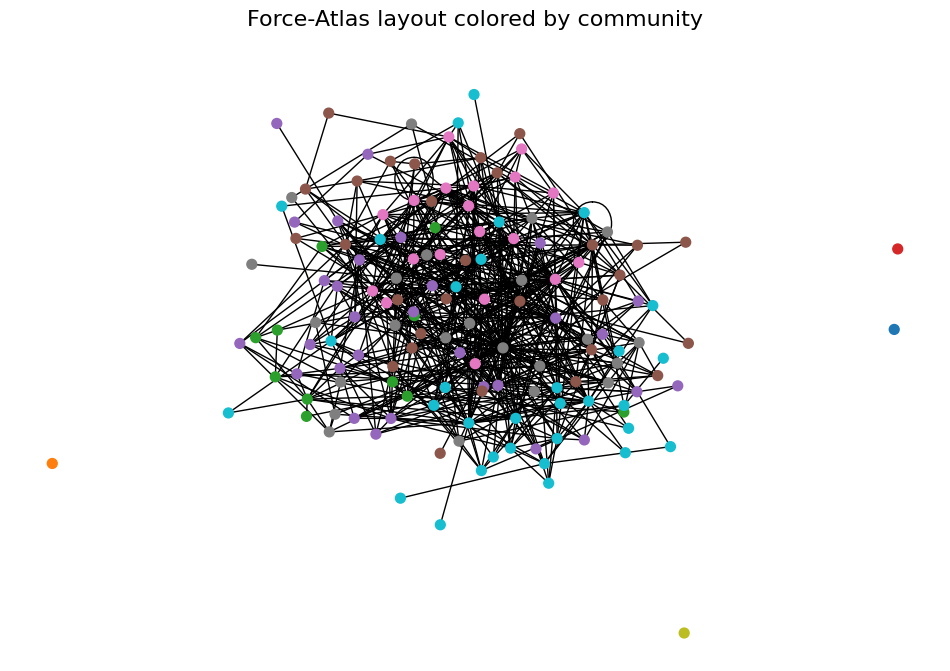

In [101]:
plot_force_atlas(louvain_dict, subnetwork)

With the help of an LLM, I tried another way to visualise the graphs, which would group the nodes in the same community closer together.

In [104]:
import numpy as np

def plot_community_aware(partition, subnetwork):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Generate a color for each community
    num_communities = len(community_list)

    # Assign each community a block position
    block_positions = {}
    block_size = 10  # Spread between communities
    for idx, community in enumerate(community_list):
        # Place each block along a circle
        angle = 2 * np.pi * idx / num_communities
        block_positions[idx] = (block_size * np.cos(angle), block_size * np.sin(angle))

    # Assign initial positions for each node based on its community
    init_pos = {}
    for idx, community in enumerate(community_list):
        bx, by = block_positions[idx]
        for node in community:
            # Add small random jitter within the block
            init_pos[node] = (bx + np.random.uniform(-1, 1), by + np.random.uniform(-1, 1))

    # Create color map based on partition
    node_colors = create_color_map(partition, subnetwork)

    # Use spring_layout with these initial positions
    pos = nx.spring_layout(subnetwork, pos=init_pos, seed=42, 
                       k=2.0,  # Increased from 0.5
                       iterations=20)

    pos_scaled = {node: (x * 20, y * 20) for node, (x, y) in pos.items()}

    plt.figure(figsize=(24, 20))
    nx.draw(subnetwork, pos=pos_scaled, node_color=node_colors, 
        with_labels=False, node_size=150, edge_color="#cccccc")
    plt.title("Community-aware layout: nodes in same community are closer")
    plt.show()

I plotted the first genre partition with the spring layout.

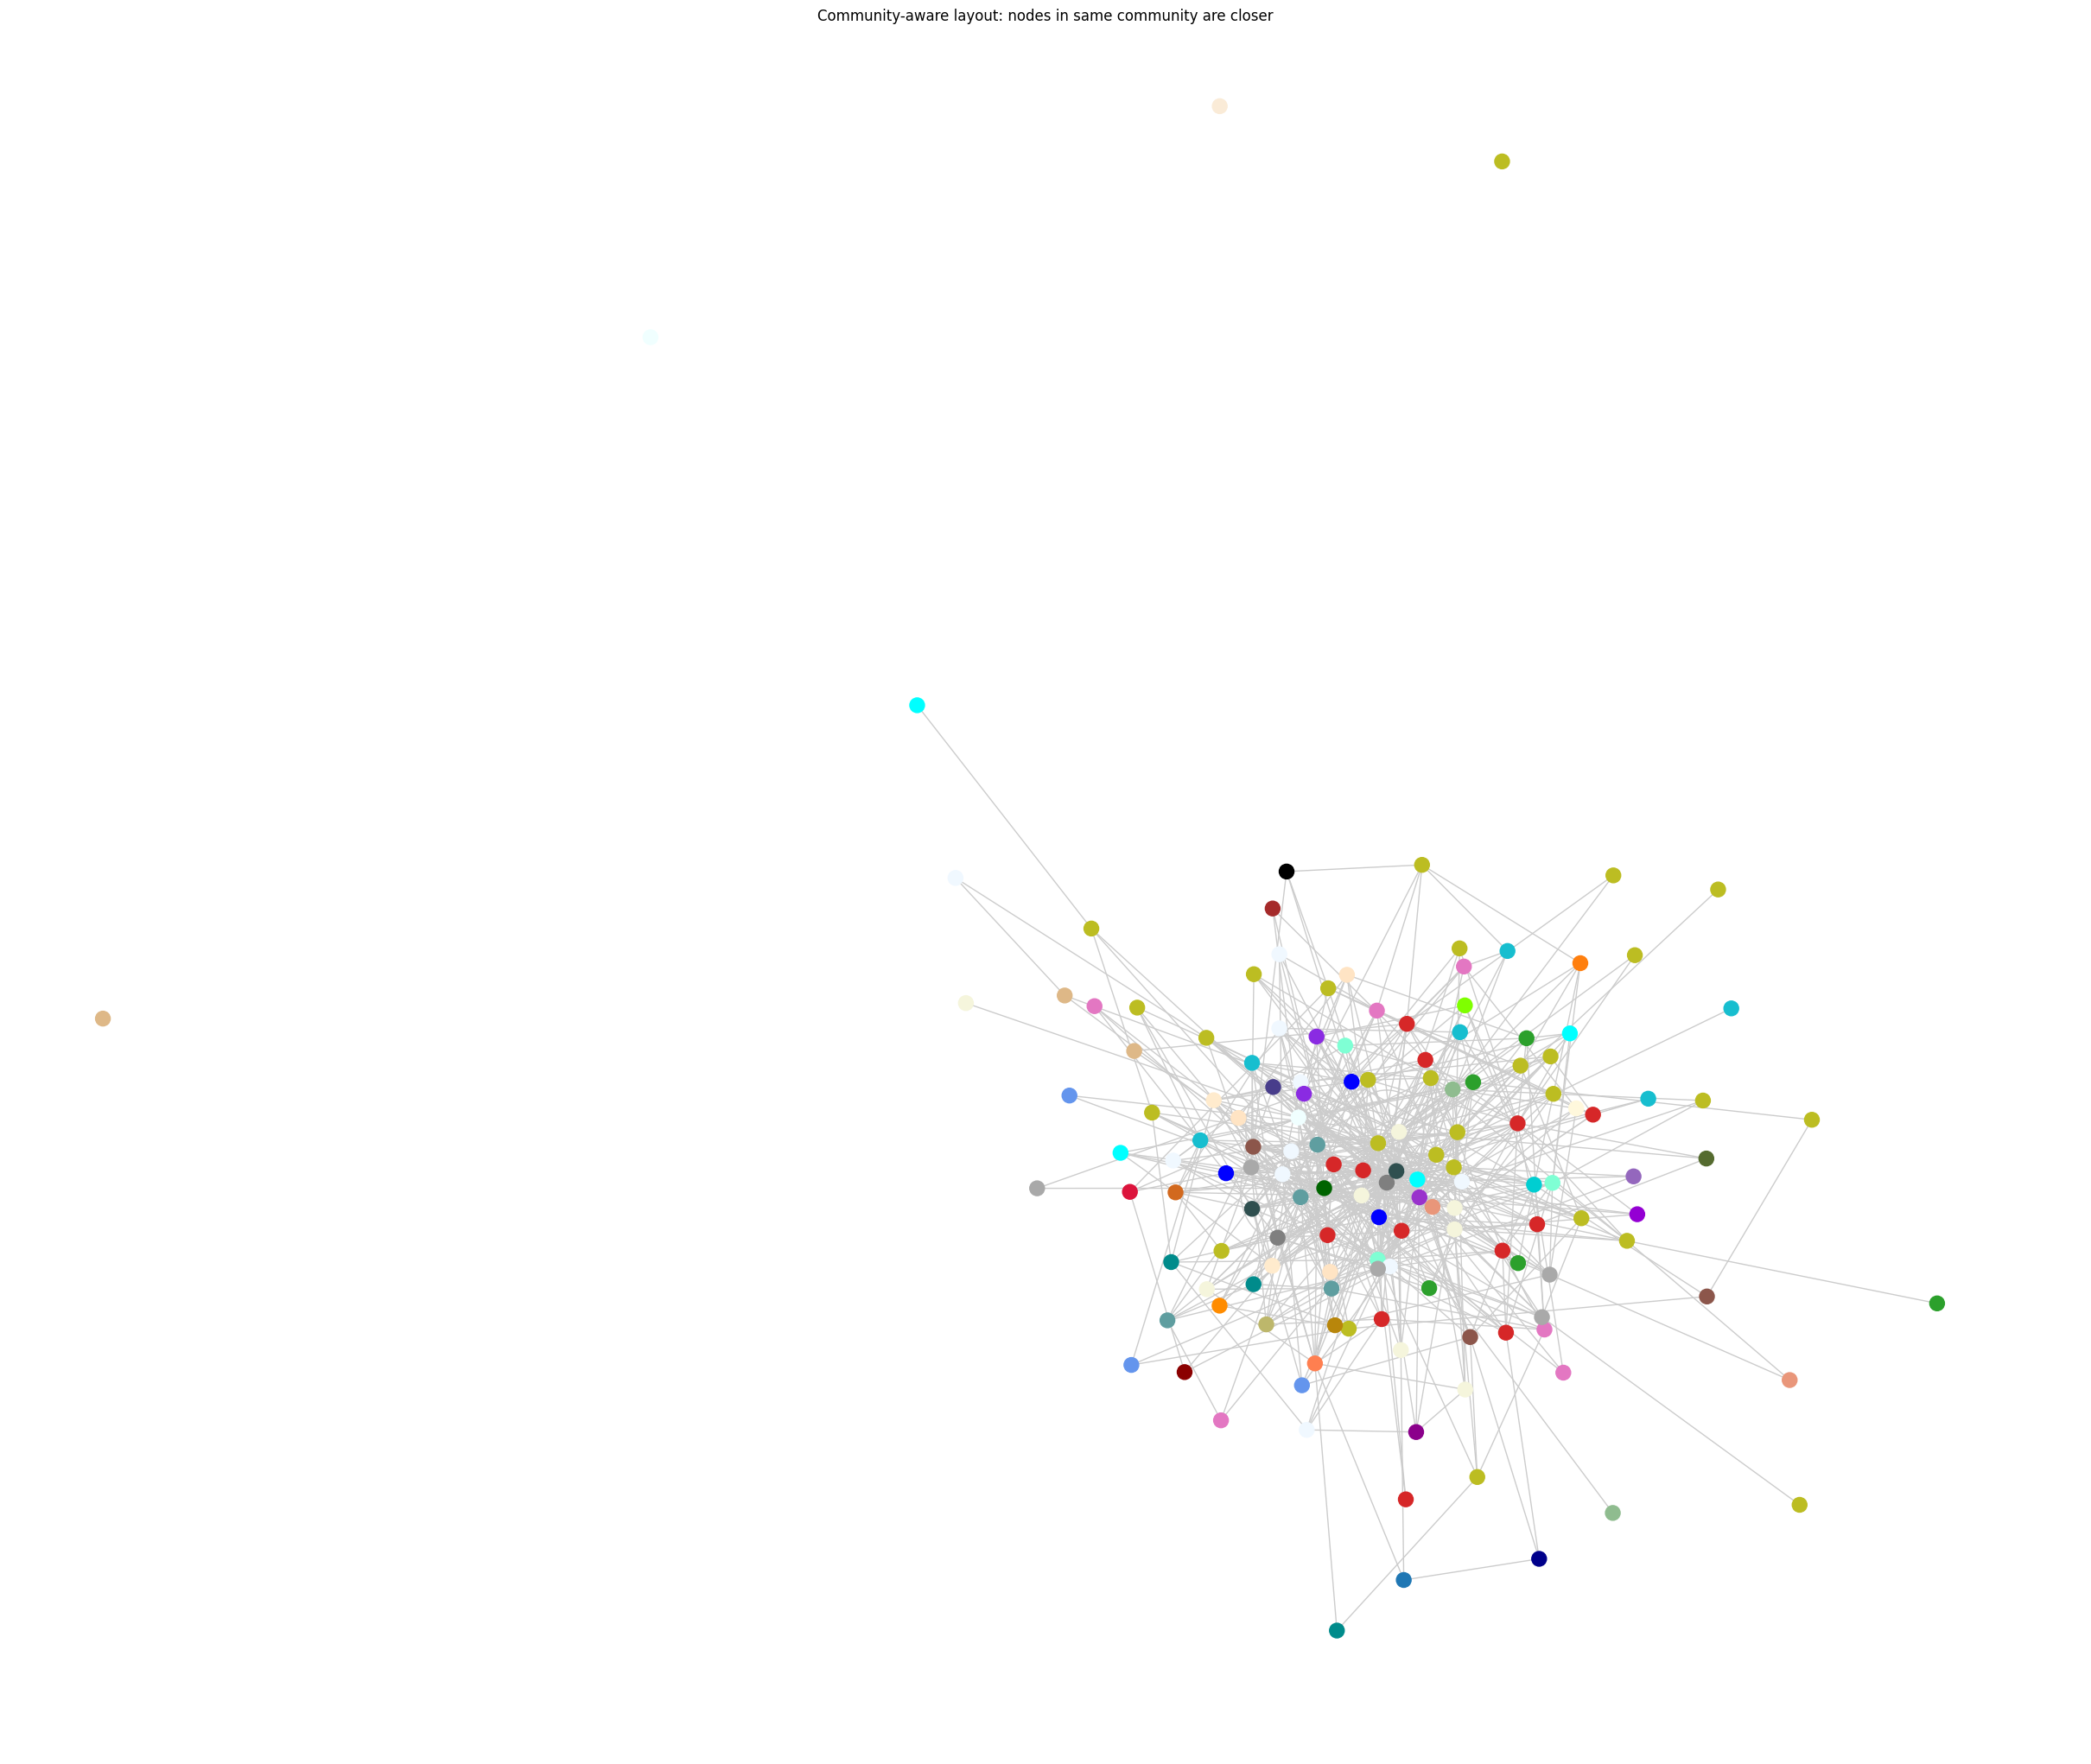

In [105]:
plot_community_aware(first_partition, subnetwork)

The updated function works better for visualising the Louvain partition, emphasizing the grouping.

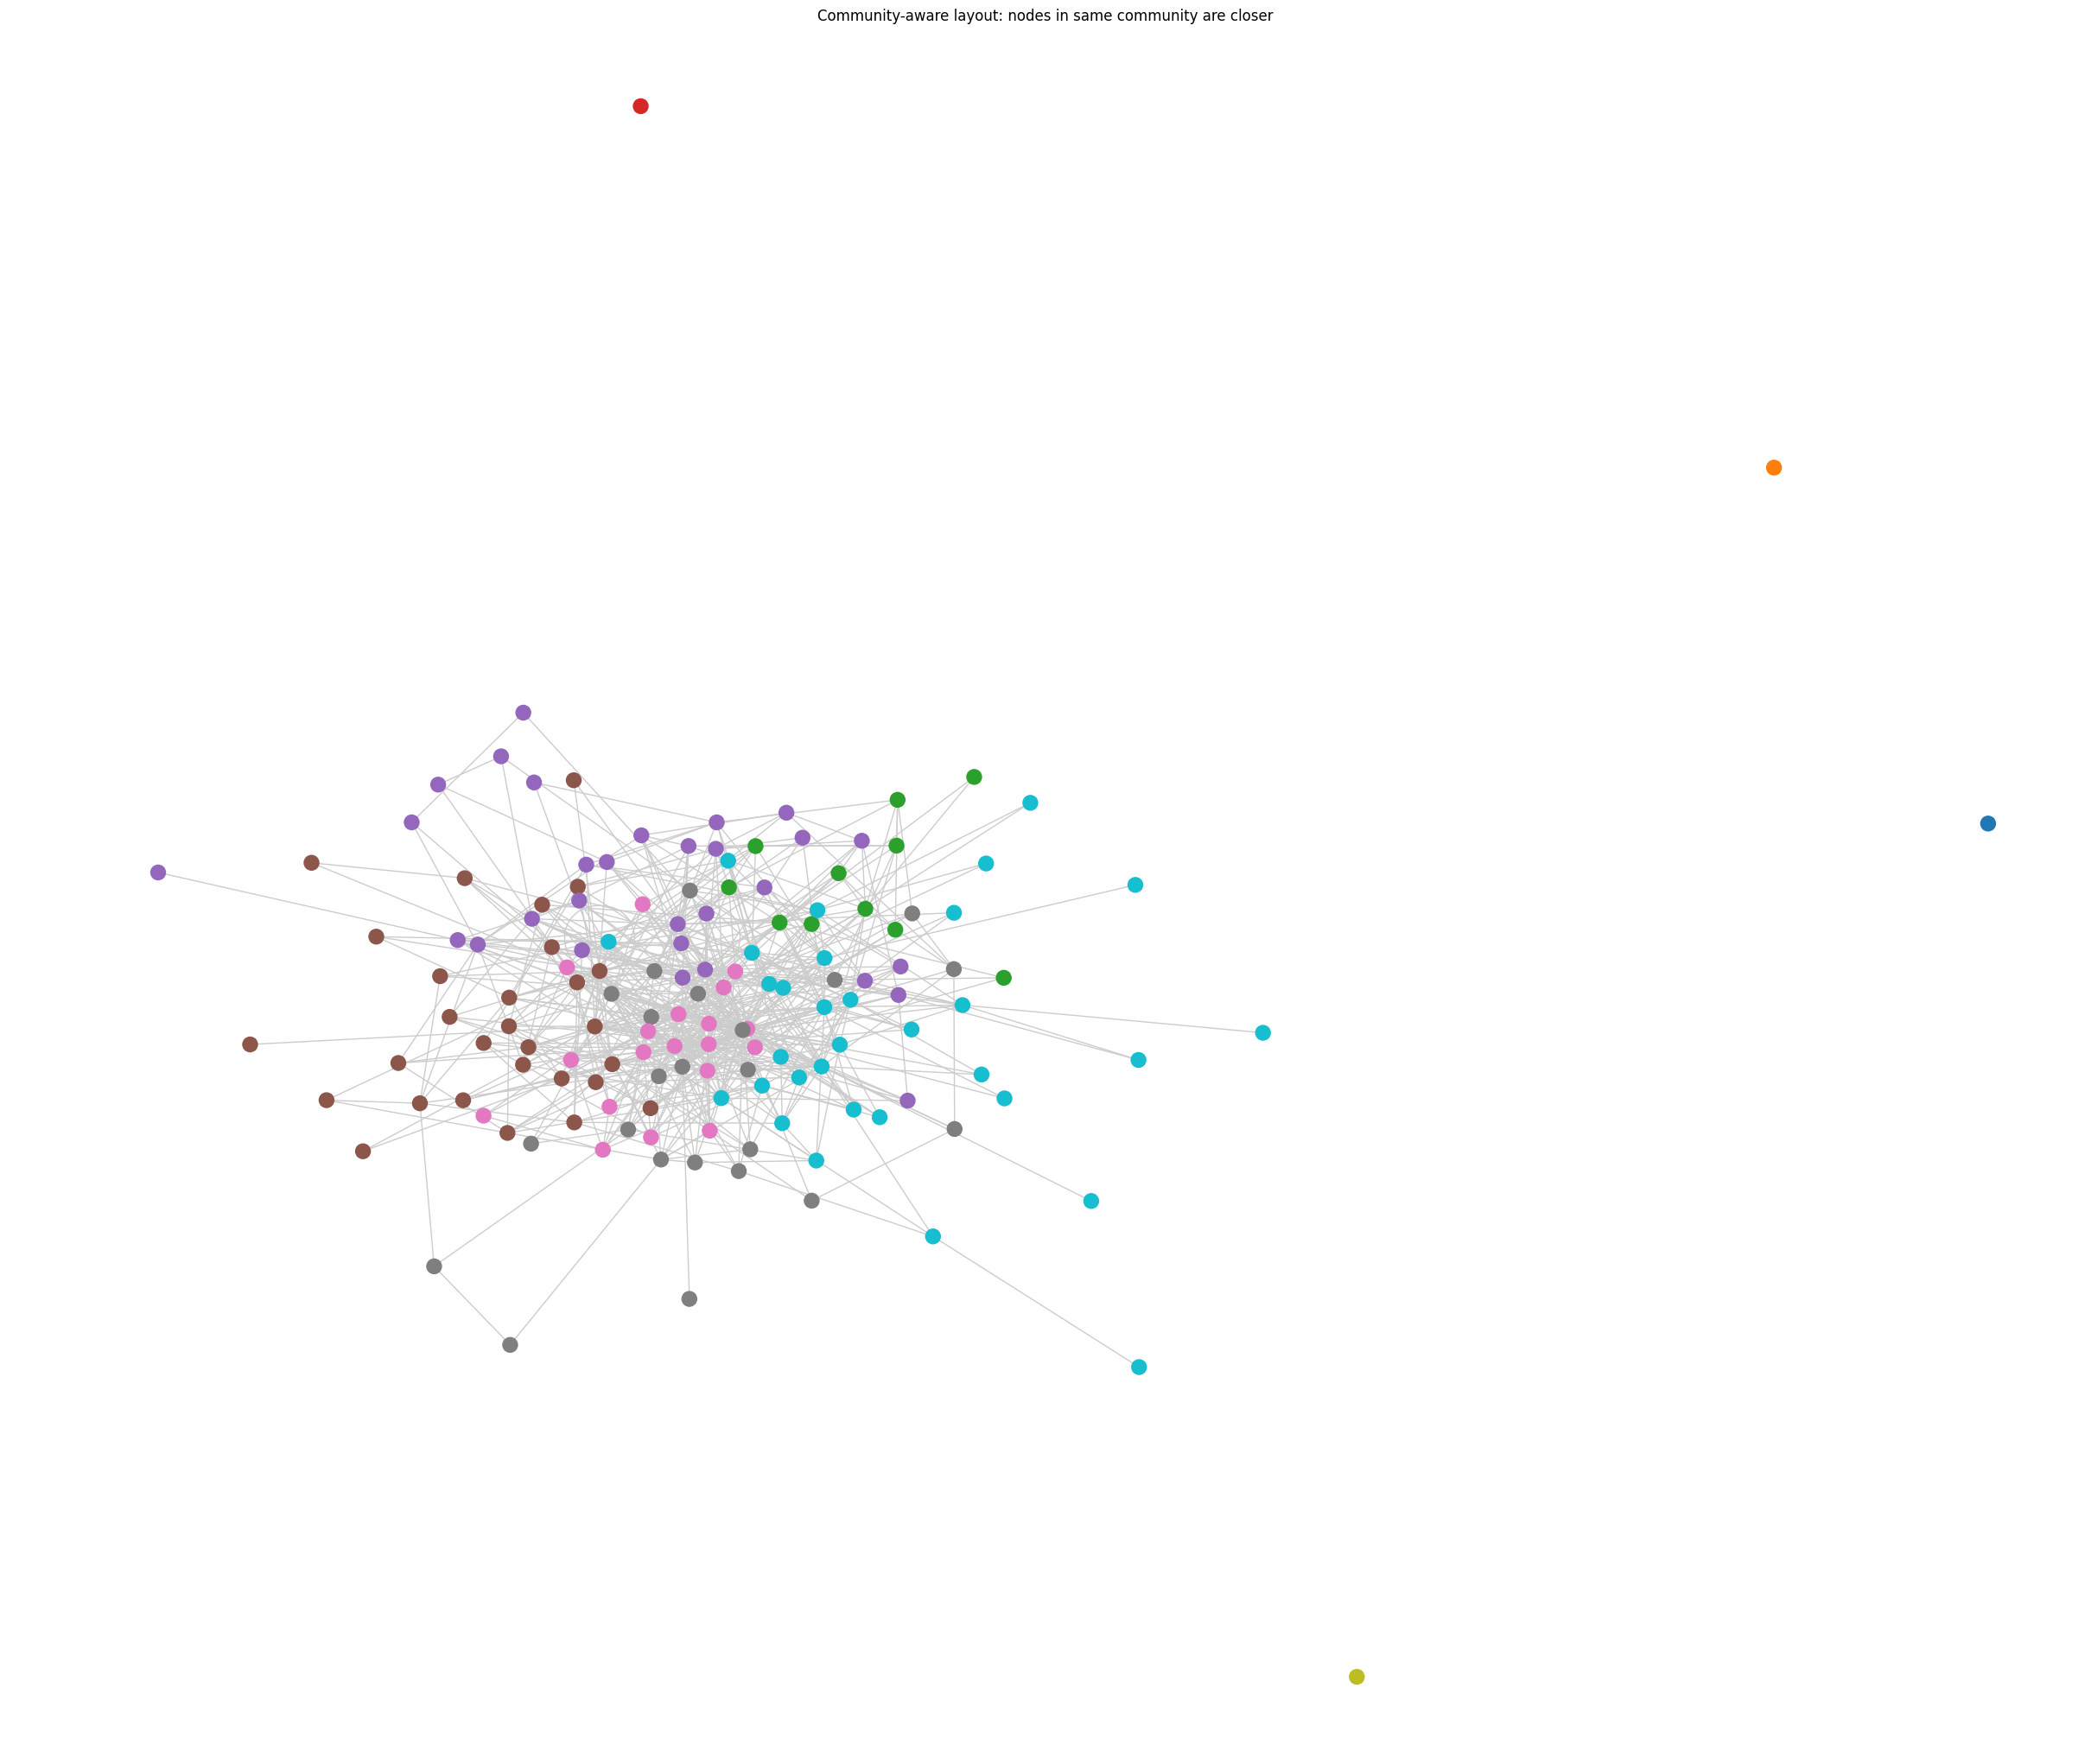

In [106]:
plot_community_aware(louvain_dict, subnetwork)

In order to visualize the backbone-edges from the network, I download the network's backbone from Github.

In [93]:
# Load the backbone
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_assignment2/refs/heads/denisa/backbone.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    backbone = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Backbone network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    backbone = None

✓ Backbone network loaded successfully!
  Nodes: 148
  Edges: 572


First, I plotted the first genre partition of the backbone with the Force Atlas algorithm.

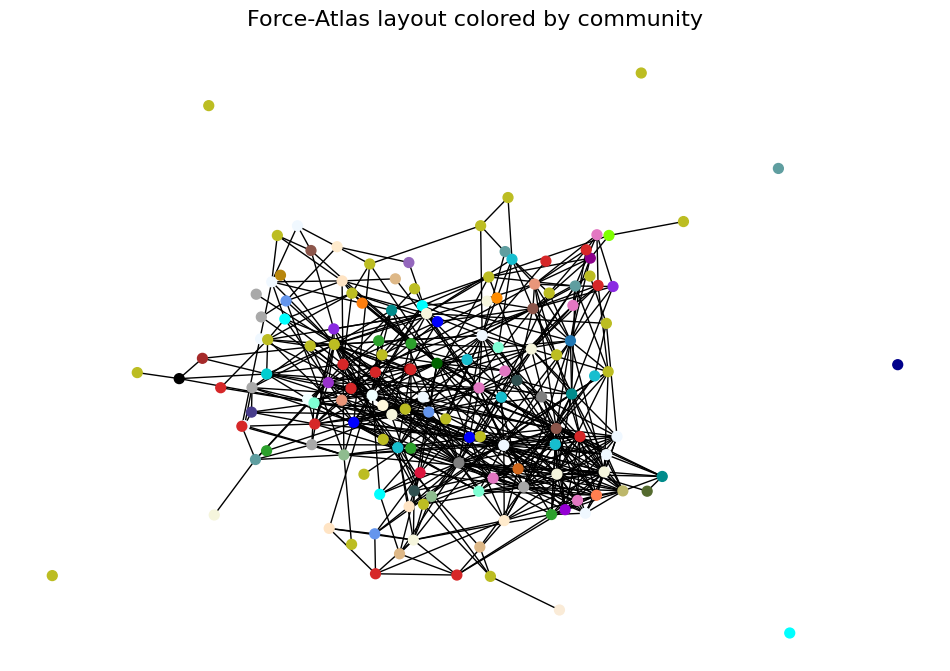

In [107]:
plot_force_atlas(first_partition, backbone)

I also plotted with my custom visualization function.

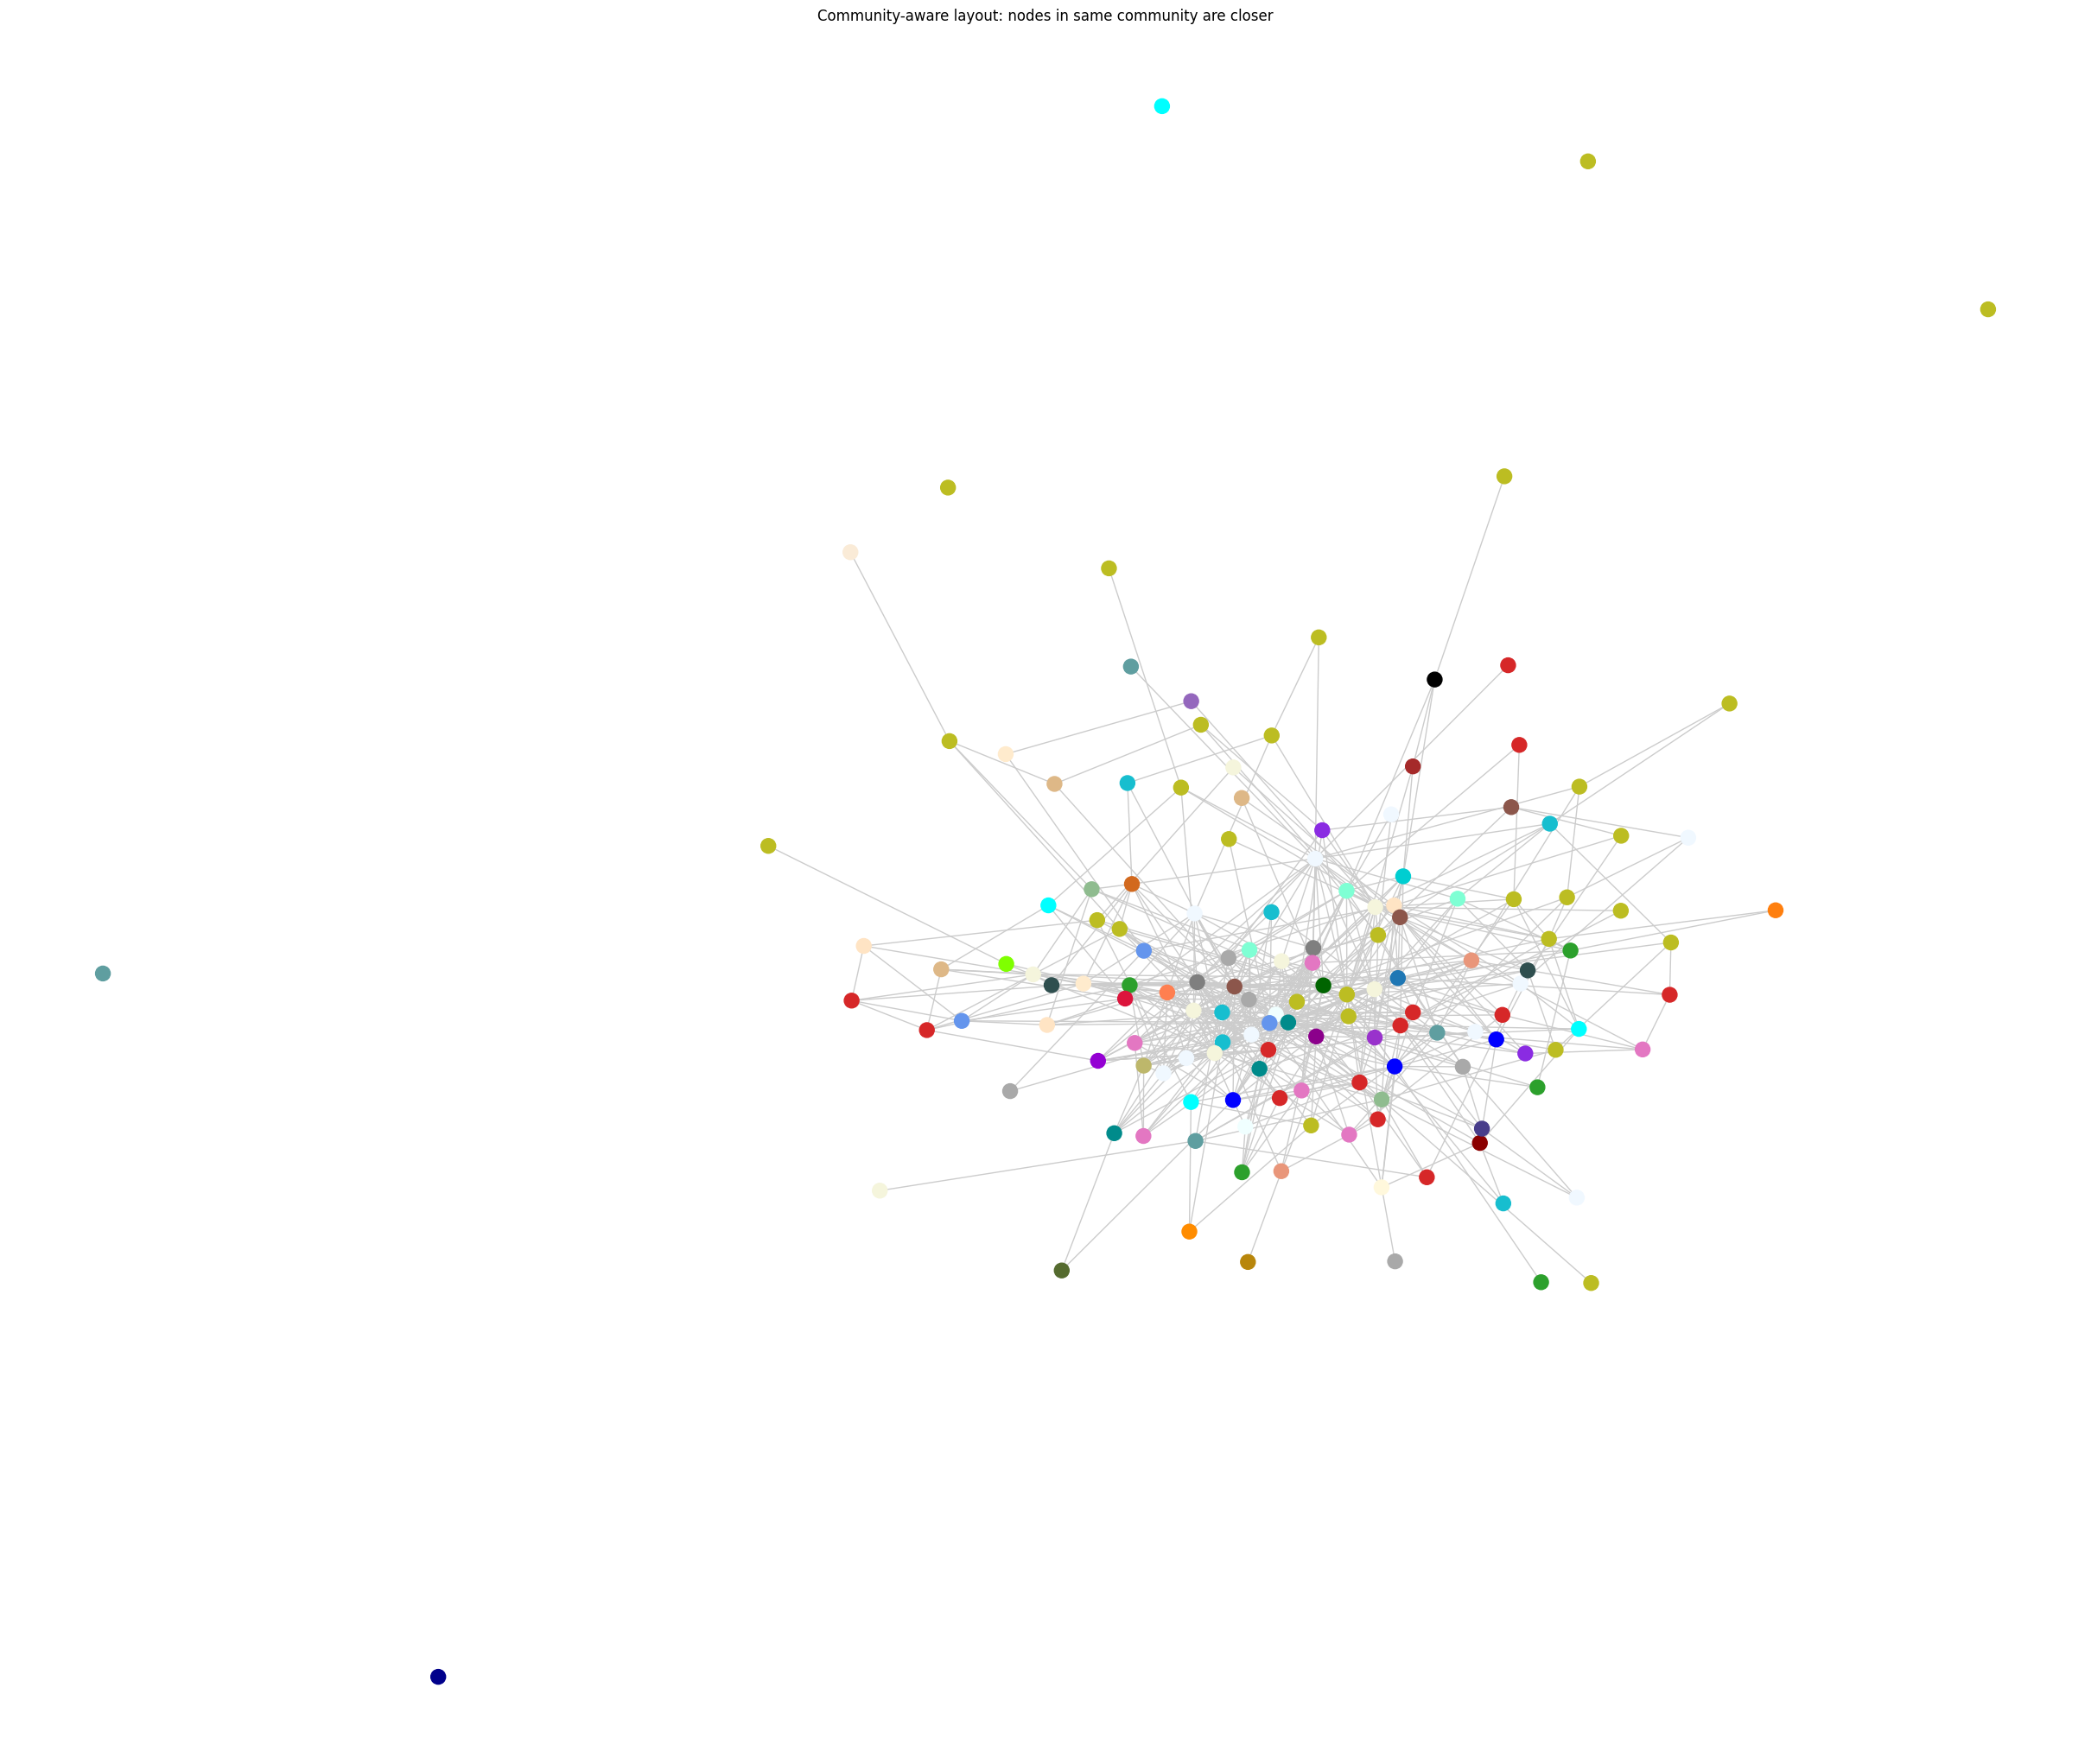

In [108]:
plot_community_aware(first_partition, backbone)

I plotted the Louvain partition of the backbone with Force Atlas.

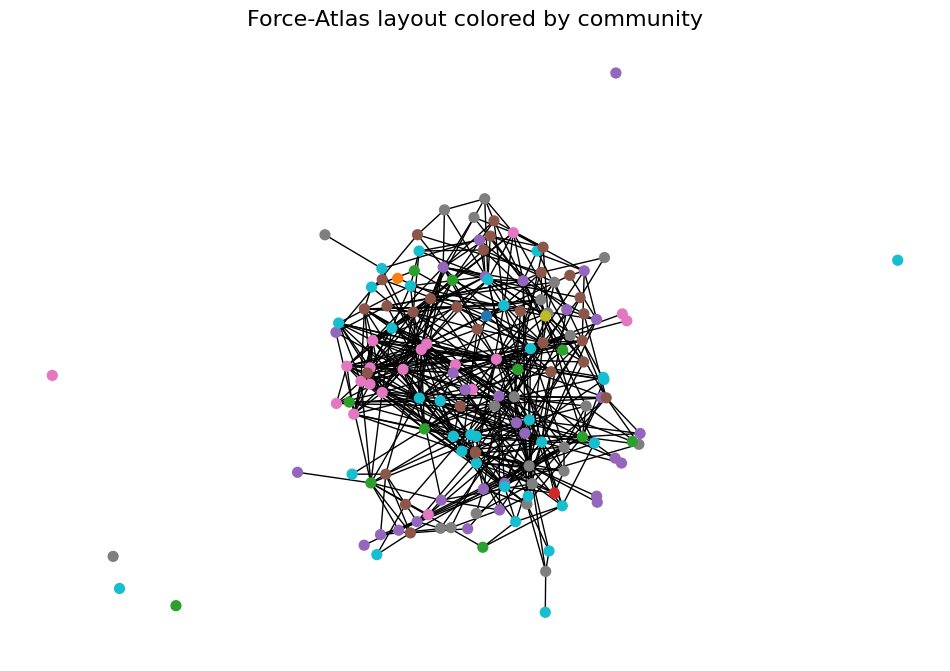

In [109]:
plot_force_atlas(louvain_dict, backbone)

Finally, I plotted with the help of my custom visualization function.

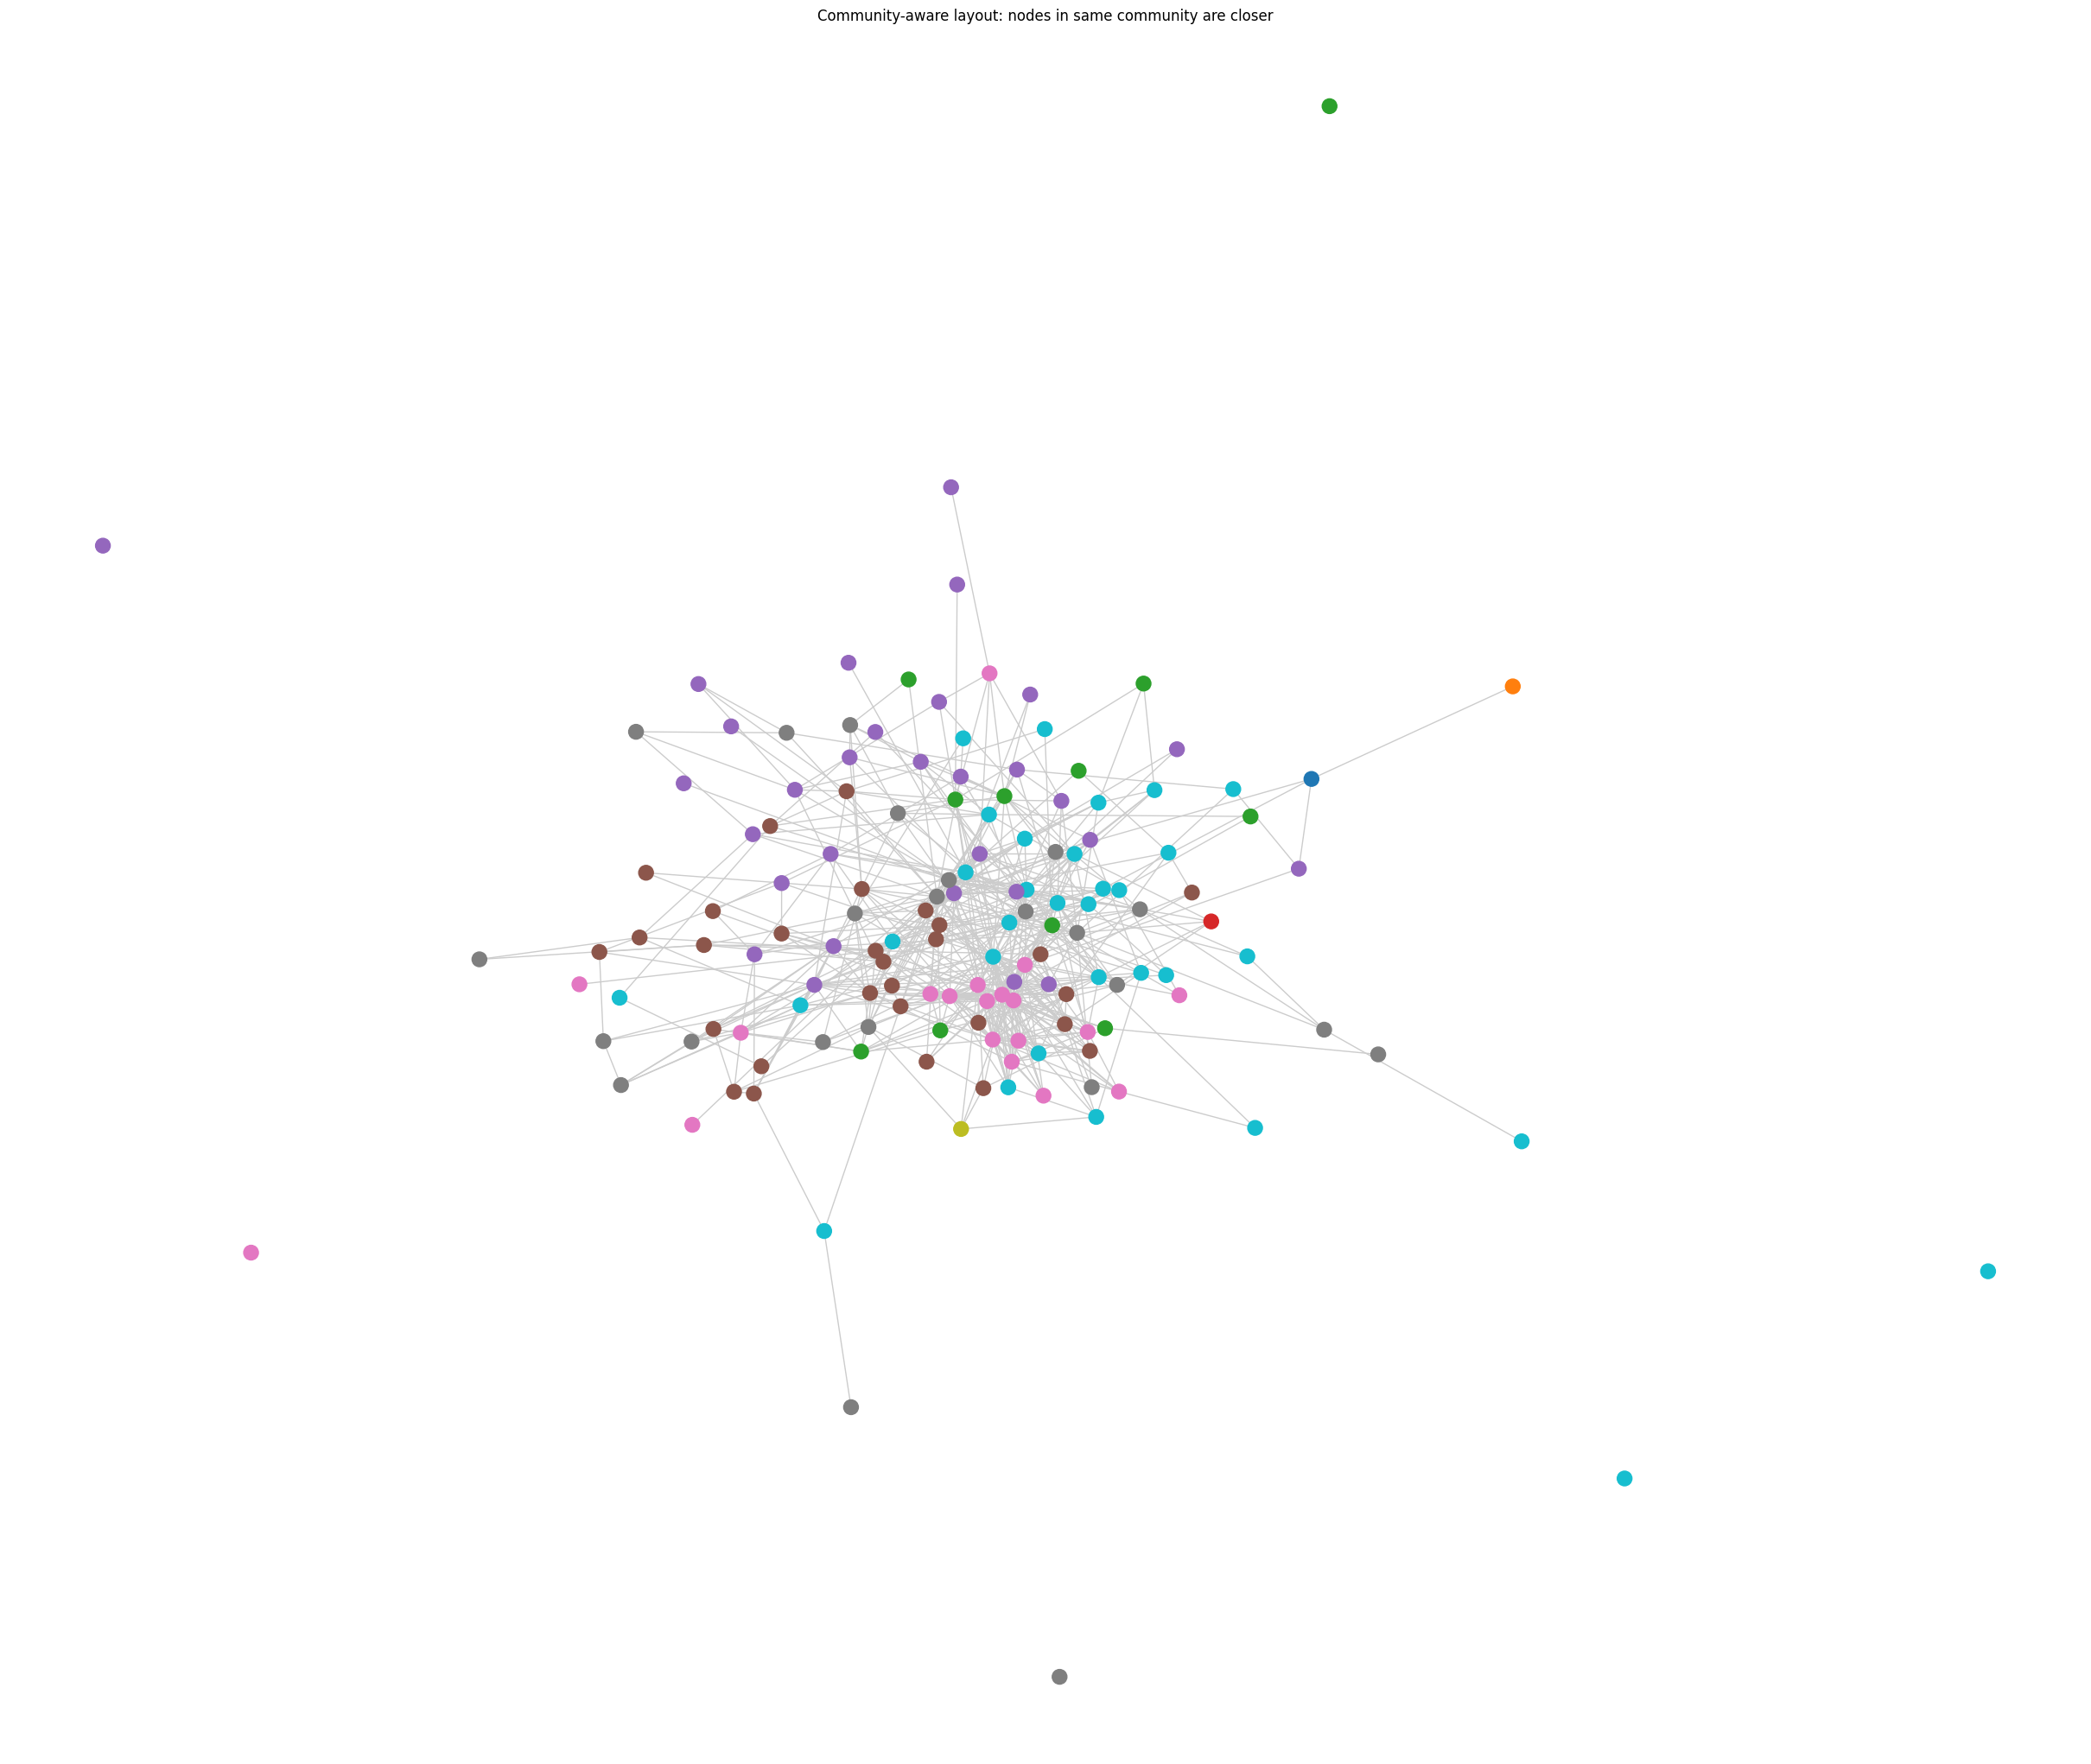

In [110]:
plot_community_aware(louvain_dict, backbone)